# ResNET50 Model

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt
import numpy as np 
import time
import pandas as pd

from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    average_precision_score
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## Constants

In [3]:
## PATH
PREPROCESSED_PATH = "/kaggle/input/datasets/shafiyahnurilhayya/movie-genre-preprocessed/preprocessed_data.pt"

## DS Consts
BATCH_SIZE  = 32
NUM_WORKERS = 2


## Load Preprocessed Data

In [4]:

data = torch.load(PREPROCESSED_PATH, map_location='cpu')

X_train        = data["X_train"]
y_train        = data["y_train"]
X_val          = data["X_val"]
y_val          = data["y_val"]
X_test         = data["X_test"]
y_test         = data["y_test"]
GENRE_COLS     = data["genre_cols"]
pos_weight     = data["pos_weight"]
sample_weights = data["sample_weights"]

print("Data berhasil dimuat:")
print(f"  X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Genre   : {GENRE_COLS}")
print(f"  GenCols : {len(GENRE_COLS)}")

N_GENRES = len(GENRE_COLS)


Data berhasil dimuat:
  X_train : torch.Size([192, 3, 224, 224])  dtype: torch.float32
  y_train : torch.Size([192, 14])
  X_val   : torch.Size([50, 3, 224, 224])
  X_test  : torch.Size([50, 3, 224, 224])
  Genre   : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']
  GenCols : 14


## Loaders

In [5]:

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_sample_weights = sample_weights[:len(X_train)]

sampler = WeightedRandomSampler(
    weights     = train_sample_weights,  
    num_samples = len(X_train),         
    replacement = True
)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
)

# Verifikasi
imgs, labels = next(iter(train_loader))
print(f"Verifikasi batch pertama:")
print(f"  imgs shape  : {tuple(imgs.shape)}   ✓")
print(f"  labels shape: {tuple(labels.shape)} ✓")
print(f"  imgs range  : [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"\nDataLoader siap. Lanjut ke definisi model.")

Verifikasi batch pertama:
  imgs shape  : (32, 3, 224, 224)   ✓
  labels shape: (32, 14) ✓
  imgs range  : [-2.12, 2.64]

DataLoader siap. Lanjut ke definisi model.


# MODEL

In [6]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

NUM_CLASSES = len(GENRE_COLS)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
model.fc = nn.Sequential(
    # nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

# Train FC layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


## Loss & Optim

In [7]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

## TRAIN CONSTANTS

In [8]:
epochs = 30

best_f1 = 0.0
best_val = 0.0

train_losses = []
val_losses = []
f1_scores = []

In [9]:
for epoch in range(epochs):

##################### TRAIN #####################
    
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * images.size(0)
        )

    train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

##################### VALIDATE #####################

    model.eval()

    running_val_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += (
                loss.item() * images.size(0)
            )

            probs = torch.sigmoid(outputs)

            all_labels.append(
                labels.cpu()
            )

            all_probs.append(
                probs.cpu()
            )

    val_loss = (
        running_val_loss / len(val_loader.dataset)
    )


##################### METRICS #####################

    all_labels = torch.cat(all_labels).numpy()

    all_probs = torch.cat(all_probs).numpy()

    all_preds = (
        all_probs > 0.5
    ).astype(int)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        average="macro"
    )


    # SAVE HISTORY

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    f1_scores.append(macro_f1)


##################### PRINTS #####################

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"ROC-AUC: {roc_auc:.4f}"
    )

    # SAVE BEST MODEL

    if macro_f1 > best_f1:

        best_f1 = macro_f1

        torch.save(
            model.state_dict(),
            "best_resnet50_model.pth"
        )

        print("Best model saved.")


    # LR STEP
    scheduler.step()

Epoch [1/30] | Train Loss: 1.1890 | Val Loss: 1.0135 | Macro F1: 0.2958 | ROC-AUC: 0.5801
Best model saved.
Epoch [2/30] | Train Loss: 1.0485 | Val Loss: 1.0165 | Macro F1: 0.2650 | ROC-AUC: 0.6145
Epoch [3/30] | Train Loss: 0.9440 | Val Loss: 1.0118 | Macro F1: 0.2944 | ROC-AUC: 0.6434
Epoch [4/30] | Train Loss: 0.8395 | Val Loss: 1.0038 | Macro F1: 0.2986 | ROC-AUC: 0.6644
Best model saved.
Epoch [5/30] | Train Loss: 0.8294 | Val Loss: 0.9646 | Macro F1: 0.3466 | ROC-AUC: 0.6949
Best model saved.
Epoch [6/30] | Train Loss: 0.7364 | Val Loss: 0.9270 | Macro F1: 0.3957 | ROC-AUC: 0.7134
Best model saved.
Epoch [7/30] | Train Loss: 0.7127 | Val Loss: 0.8980 | Macro F1: 0.4318 | ROC-AUC: 0.7243
Best model saved.
Epoch [8/30] | Train Loss: 0.6513 | Val Loss: 0.8771 | Macro F1: 0.4520 | ROC-AUC: 0.7307
Best model saved.
Epoch [9/30] | Train Loss: 0.5930 | Val Loss: 0.8668 | Macro F1: 0.4532 | ROC-AUC: 0.7327
Best model saved.
Epoch [10/30] | Train Loss: 0.5725 | Val Loss: 0.8691 | Macro F1

## GRAPHs

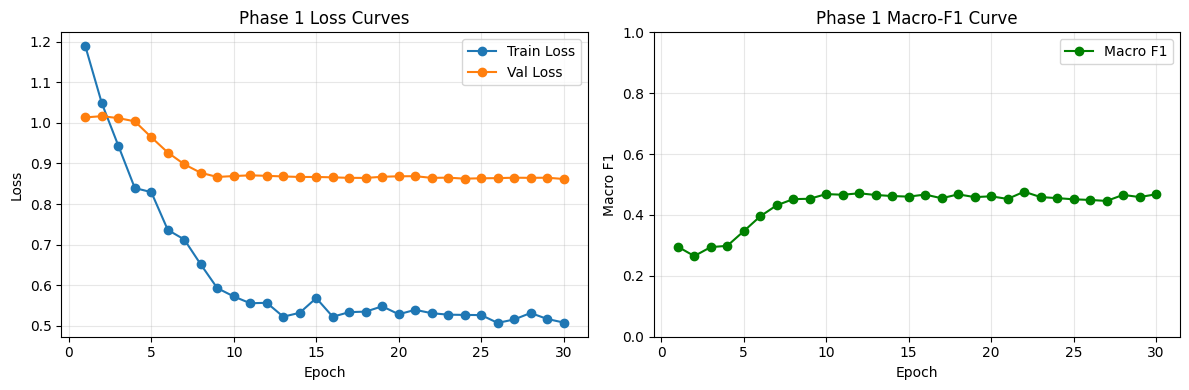

In [10]:
phase1_epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(phase1_epochs, train_losses, label="Train Loss", marker="o")
plt.plot(phase1_epochs, val_losses, label="Val Loss", marker="o")
plt.title("Phase 1 Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phase1_epochs, f1_scores, label="Macro F1", color="green", marker="o")
plt.title("Phase 1 Macro-F1 Curve")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Model Eval

In [11]:
print("\nFinal Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=GENRE_COLS,
        zero_division=0
    )
)


Final Classification Report:

              precision    recall  f1-score   support

      action       0.81      0.71      0.76        35
   adventure       0.77      0.80      0.78        25
   animation       0.53      1.00      0.69        10
      comedy       0.53      0.56      0.55        16
       crime       0.44      0.40      0.42        10
       drama       0.70      0.55      0.62        29
      family       0.33      0.71      0.45         7
     fantasy       0.44      0.47      0.45        15
      horror       0.00      0.00      0.00         3
     musical       0.14      1.00      0.25         1
     mystery       0.29      0.25      0.27         8
     romance       0.25      0.56      0.34         9
       scifi       0.41      0.50      0.45        14
    thriller       0.78      0.39      0.52        18

   micro avg       0.52      0.59      0.56       200
   macro avg       0.46      0.56      0.47       200
weighted avg       0.60      0.59      0.57      

## PHASE 2 POWERSPIKE

## MODEL

In [12]:
model.load_state_dict(
    torch.load("best_resnet50_model.pth")
)

for param in model.layer4.parameters():
    param.requires_grad = True

## OPTIMIZER

In [13]:
optimizer = optim.Adam([
    {
        'params': model.layer4.parameters(),
        'lr': 1e-5
    },
    {
        'params': model.fc.parameters(),
        'lr': 1e-4
    }
])

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)

## ROUND 2!! Fight

In [14]:
FINETUNE_EPOCH = 20

for epoch in range(FINETUNE_EPOCH):

##################### TRAIN #####################
    
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * images.size(0)
        )

    train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

##################### VALIDATE #####################

    model.eval()

    running_val_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += (
                loss.item() * images.size(0)
            )

            probs = torch.sigmoid(outputs)

            all_labels.append(
                labels.cpu()
            )

            all_probs.append(
                probs.cpu()
            )

    val_loss = (
        running_val_loss / len(val_loader.dataset)
    )


##################### METRICS #####################

    all_labels = torch.cat(all_labels).numpy()

    all_probs = torch.cat(all_probs).numpy()

    all_preds = (
        all_probs > 0.5
    ).astype(int)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        average="macro"
    )


    # SAVE HISTORY

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    f1_scores.append(macro_f1)


##################### PRINTS #####################

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Macro F1: {macro_f1:.4f} | "
        f"ROC-AUC: {roc_auc:.4f}"
    )

    # SAVE BEST MODEL

    if macro_f1 > best_f1:

        best_f1 = macro_f1

        torch.save(
            model.state_dict(),
            "best_resnet50_fine_model.pth"
        )

        print("Best model saved.")


    # LR STEP
    scheduler.step()

Epoch [1/30] | Train Loss: 0.5160 | Val Loss: 0.8622 | Macro F1: 0.4750 | ROC-AUC: 0.7327
Epoch [2/30] | Train Loss: 0.4926 | Val Loss: 0.8593 | Macro F1: 0.4798 | ROC-AUC: 0.7335
Best model saved.
Epoch [3/30] | Train Loss: 0.4512 | Val Loss: 0.8630 | Macro F1: 0.4848 | ROC-AUC: 0.7328
Best model saved.
Epoch [4/30] | Train Loss: 0.4485 | Val Loss: 0.8626 | Macro F1: 0.4968 | ROC-AUC: 0.7378
Best model saved.
Epoch [5/30] | Train Loss: 0.4239 | Val Loss: 0.8599 | Macro F1: 0.4861 | ROC-AUC: 0.7372
Epoch [6/30] | Train Loss: 0.4310 | Val Loss: 0.8613 | Macro F1: 0.4812 | ROC-AUC: 0.7373
Epoch [7/30] | Train Loss: 0.4151 | Val Loss: 0.8609 | Macro F1: 0.4751 | ROC-AUC: 0.7374
Epoch [8/30] | Train Loss: 0.4183 | Val Loss: 0.8661 | Macro F1: 0.4664 | ROC-AUC: 0.7339
Epoch [9/30] | Train Loss: 0.4252 | Val Loss: 0.8662 | Macro F1: 0.4756 | ROC-AUC: 0.7334
Epoch [10/30] | Train Loss: 0.4056 | Val Loss: 0.8713 | Macro F1: 0.4744 | ROC-AUC: 0.7312
Epoch [11/30] | Train Loss: 0.3846 | Val Loss

## Graph

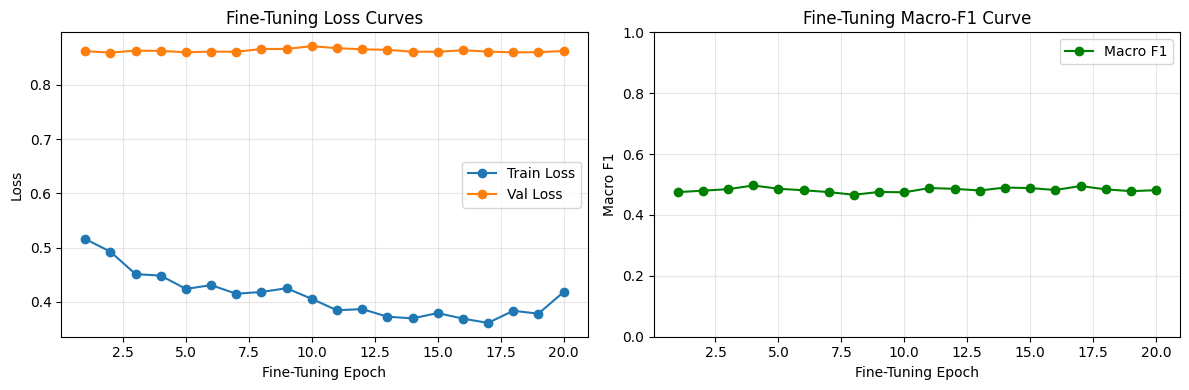

In [15]:
phase1_len = epochs
phase2_train_losses = train_losses[phase1_len:]
phase2_val_losses = val_losses[phase1_len:]
phase2_f1_scores = f1_scores[phase1_len:]

if len(phase2_train_losses) == 0:
    print("Fine-tuning history is empty. Run the fine-tuning cell first.")
else:
    phase2_epochs = list(range(1, len(phase2_train_losses) + 1))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(phase2_epochs, phase2_train_losses, label="Train Loss", marker="o")
    plt.plot(phase2_epochs, phase2_val_losses, label="Val Loss", marker="o")
    plt.title("Fine-Tuning Loss Curves")
    plt.xlabel("Fine-Tuning Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(phase2_epochs, phase2_f1_scores, label="Macro F1", color="green", marker="o")
    plt.title("Fine-Tuning Macro-F1 Curve")
    plt.xlabel("Fine-Tuning Epoch")
    plt.ylabel("Macro F1")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

## TEST EVAL

## TEST CONSTS

In [16]:
THRESHOLD = 0.50

test_loss = 0.0

all_labels = []
all_probs = []

total_inference_time = 0.0
total_images = 0

## EVAL ACTUAL

In [17]:
model.load_state_dict(
    torch.load("best_resnet50_fine_model.pth")
)

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.float().to(device)


        # Measure inference time non CUDA
        # start_time = time.time()

        # outputs = model(images)

        # end_time = time.time()

        # Measure inference time CUDA
        torch.cuda.synchronize()

        start_time = time.time()

        outputs = model(images)

        torch.cuda.synchronize()

        end_time = time.time()

        total_inference_time += (
            end_time - start_time
        )

        total_images += images.size(0)


        # Compute loss


        loss = criterion(outputs, labels)

        test_loss += (
            loss.item() * images.size(0)
        )


        # Convert logits to probabilities


        probs = torch.sigmoid(outputs)

        all_labels.append(
            labels.cpu()
        )

        all_probs.append(
            probs.cpu()
        )
        


## Report Compose

In [18]:
test_loss /= len(test_loader.dataset)

all_labels = torch.cat(
    all_labels
).numpy()

all_probs = torch.cat(
    all_probs
).numpy()


all_preds = (
    all_probs >= THRESHOLD
).astype(int)

report = classification_report(
    all_labels,
    all_preds,
    target_names=GENRE_COLS,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()


## Metric

In [19]:
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

micro_f1 = f1_score(
    all_labels,
    all_preds,
    average="micro",
    zero_division=0
)

hamming = hamming_loss(
    all_labels,
    all_preds
)

exact_match = accuracy_score(
    all_labels,
    all_preds
)

weighted_auc = roc_auc_score(
    all_labels,
    all_probs,
    average="weighted"
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

avg_inference_time = (
    total_inference_time / total_images
)

# If you tracked epoch times earlier:
# avg_train_epoch_time = sum(epoch_times)/len(epoch_times)

# Placeholder if unavailable
avg_train_epoch_time = None

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## Printer

In [20]:
print("\n================================================")
print("FINAL TEST EVALUATION")
print("================================================\n")

# -------------------------------------------------
# Per-genre metrics
# -------------------------------------------------

print("PER-GENRE PERFORMANCE METRICS:\n")

print(
    report_df.loc[
        GENRE_COLS,
        ["precision", "recall", "f1-score", "support"]
    ]
)

# -------------------------------------------------
# Overall metrics
# -------------------------------------------------

print("\n================================================")
print("OVERALL MODEL PERFORMANCE")
print("================================================\n")

print(f"Validation/Test Loss      : {test_loss:.4f}")

print(f"Micro AVG F1-score        : {micro_f1:.4f}")
print(f"Macro AVG F1-score        : {macro_f1:.4f}")
print(f"Weighted AVG F1-score     : {weighted_f1:.4f}")

print(f"Hamming Loss              : {hamming:.4f}")

print(f"Exact Match Accuracy      : {exact_match:.4f}")

print(f"Weighted ROC-AUC          : {weighted_auc:.4f}")

print(f"Total Parameters          : {total_params:,}")
print(f"Trainable Parameters      : {trainable_params:,}")

if avg_train_epoch_time is not None:
    print(
        f"Training Time / Epoch     : "
        f"{avg_train_epoch_time:.2f} sec"
    )

print(
    f"Inference Time / Image    : "
    f"{avg_inference_time*1000:.2f} ms"
)

# -------------------------------------------------
# Micro / Macro / Weighted Averages
# -------------------------------------------------

print("\n================================================")
print("AVERAGE METRICS")
print("================================================\n")

print(
    report_df.loc[
        ["micro avg", "macro avg", "weighted avg"],
        ["precision", "recall", "f1-score"]
    ]
)


FINAL TEST EVALUATION

PER-GENRE PERFORMANCE METRICS:

           precision    recall  f1-score  support
action      0.800000  0.555556  0.655738     36.0
adventure   0.615385  0.727273  0.666667     22.0
animation   0.500000  1.000000  0.666667      8.0
comedy      0.636364  0.538462  0.583333     13.0
crime       0.461538  0.461538  0.461538     13.0
drama       0.807692  0.617647  0.700000     34.0
family      0.214286  0.750000  0.333333      4.0
fantasy     0.266667  0.363636  0.307692     11.0
horror      0.111111  0.333333  0.166667      3.0
musical     0.000000  0.000000  0.000000      0.0
mystery     0.466667  0.538462  0.500000     13.0
romance     0.000000  0.000000  0.000000      1.0
scifi       0.333333  0.285714  0.307692     14.0
thriller    0.727273  0.380952  0.500000     21.0

OVERALL MODEL PERFORMANCE

Validation/Test Loss      : 0.8298
Micro AVG F1-score        : 0.5085
Macro AVG F1-score        : 0.4178
Weighted AVG F1-score     : 0.5571
Hamming Loss              

INFERENSI — Contoh Prediksi pada Test Set
Threshold  : 0.5 (seragam, sama dengan model lain)
Seed       : 42 (seragam, sama dengan model lain)
N sampel   : 10
✓ sample_indices dibuat dan disimpan ke: /kaggle/working/sample_indices.npy
  Indeks   : [3, 4, 9, 19, 28, 32, 33, 39, 44, 49]

────────────────────────────────────────────────────────────


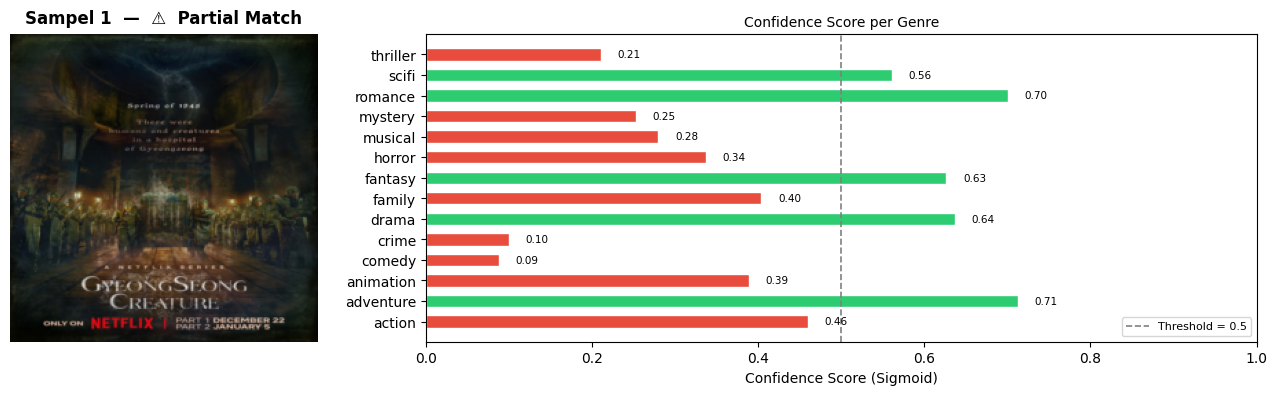


Sampel 1:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'drama', 'horror', 'mystery', 'thriller']
  Prediksi     : ['adventure', 'drama', 'fantasy', 'romance', 'scifi']
  Benar  (TP)  : ['drama']
  Terlewat(FN) : ['action', 'horror', 'mystery', 'thriller']
  Salah  (FP)  : ['adventure', 'fantasy', 'romance', 'scifi']
────────────────────────────────────────────────────────────


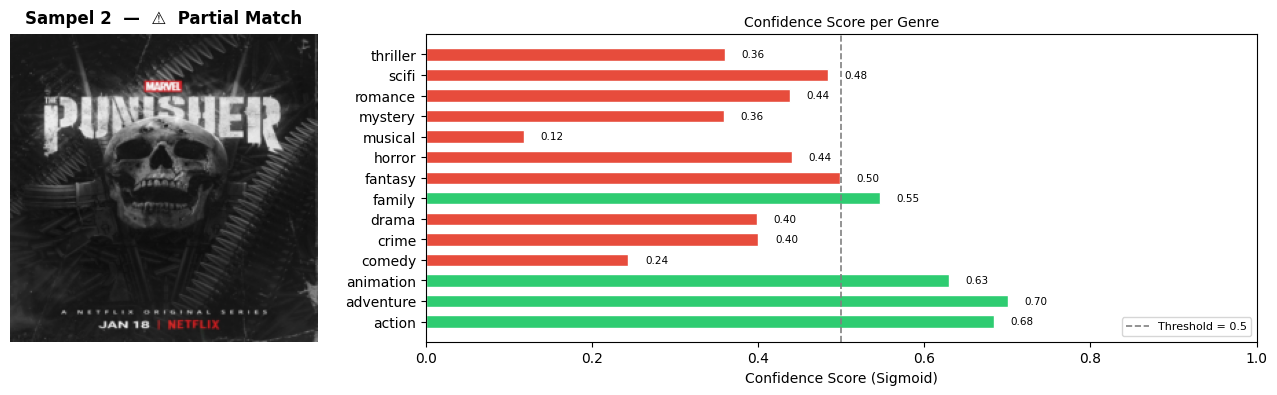


Sampel 2:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'thriller']
  Prediksi     : ['action', 'adventure', 'animation', 'family']
  Benar  (TP)  : ['action']
  Terlewat(FN) : ['crime', 'drama', 'thriller']
  Salah  (FP)  : ['adventure', 'animation', 'family']
────────────────────────────────────────────────────────────


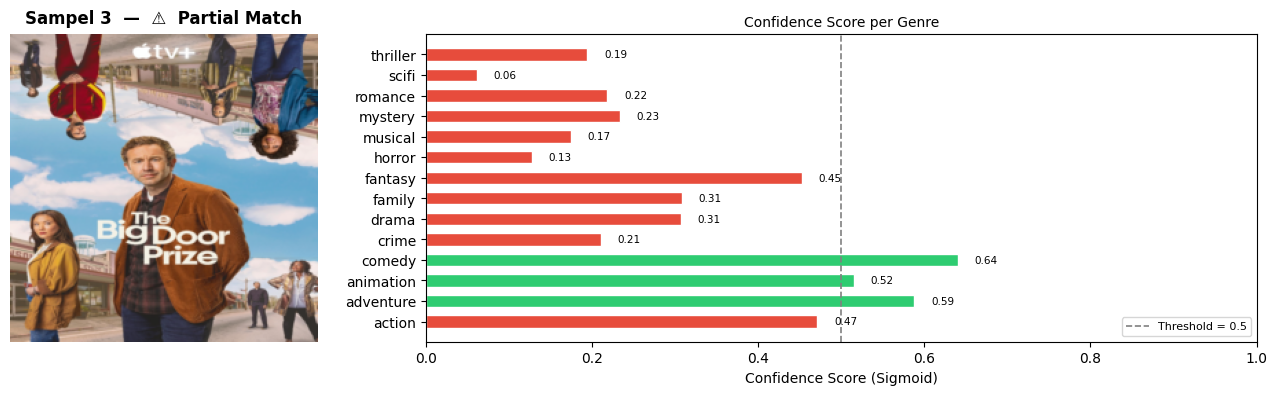


Sampel 3:
  Status       : ⚠️  Partial Match
  Label asli   : ['comedy', 'drama', 'mystery', 'scifi']
  Prediksi     : ['adventure', 'animation', 'comedy']
  Benar  (TP)  : ['comedy']
  Terlewat(FN) : ['drama', 'mystery', 'scifi']
  Salah  (FP)  : ['adventure', 'animation']
────────────────────────────────────────────────────────────


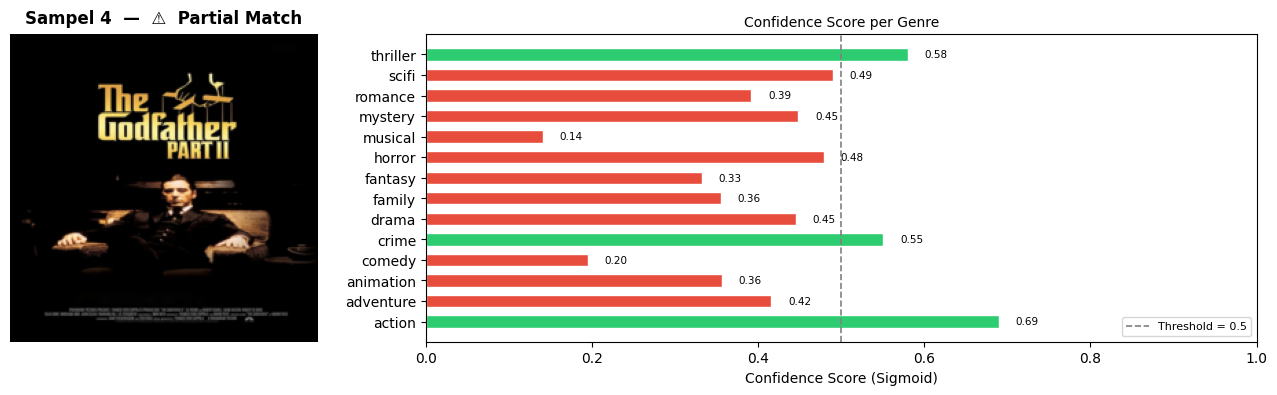


Sampel 4:
  Status       : ⚠️  Partial Match
  Label asli   : ['crime', 'drama']
  Prediksi     : ['action', 'crime', 'thriller']
  Benar  (TP)  : ['crime']
  Terlewat(FN) : ['drama']
  Salah  (FP)  : ['action', 'thriller']
────────────────────────────────────────────────────────────


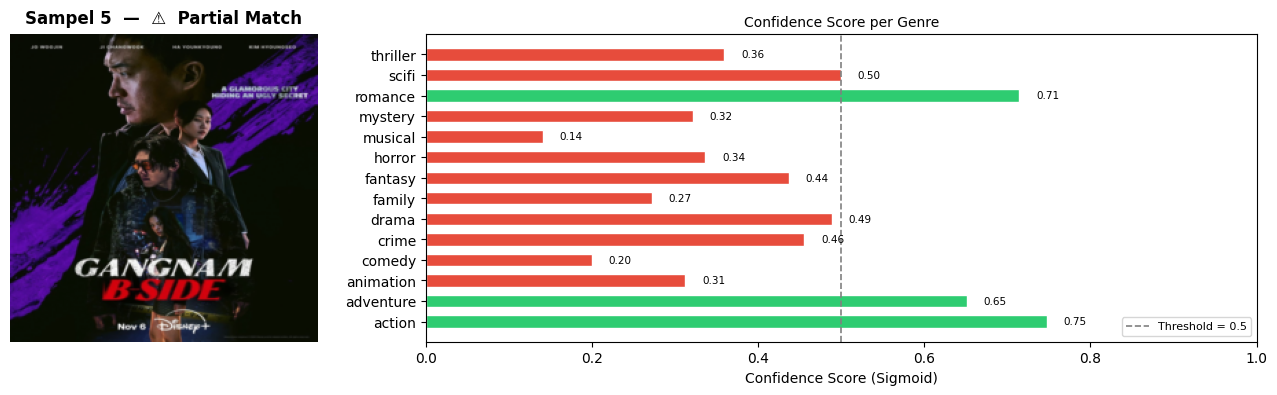


Sampel 5:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'mystery', 'thriller']
  Prediksi     : ['action', 'adventure', 'romance']
  Benar  (TP)  : ['action']
  Terlewat(FN) : ['crime', 'drama', 'mystery', 'thriller']
  Salah  (FP)  : ['adventure', 'romance']
────────────────────────────────────────────────────────────


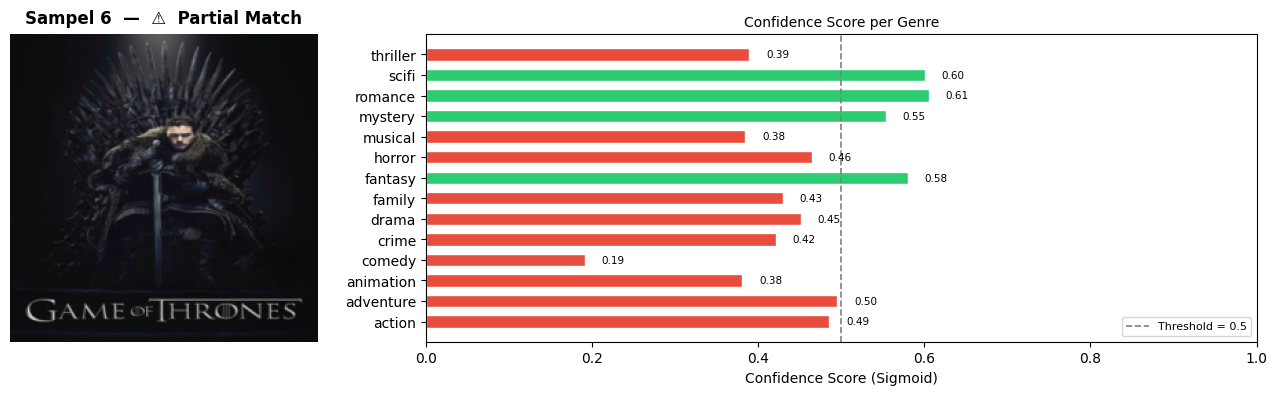


Sampel 6:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'fantasy']
  Prediksi     : ['fantasy', 'mystery', 'romance', 'scifi']
  Benar  (TP)  : ['fantasy']
  Terlewat(FN) : ['action', 'adventure']
  Salah  (FP)  : ['mystery', 'romance', 'scifi']
────────────────────────────────────────────────────────────


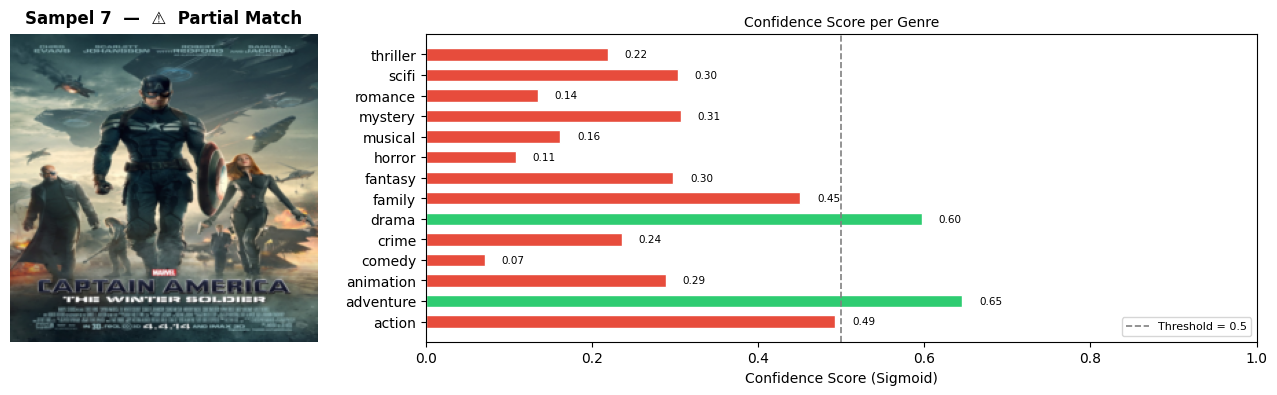


Sampel 7:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi', 'thriller']
  Prediksi     : ['adventure', 'drama']
  Benar  (TP)  : ['adventure']
  Terlewat(FN) : ['action', 'scifi', 'thriller']
  Salah  (FP)  : ['drama']
────────────────────────────────────────────────────────────


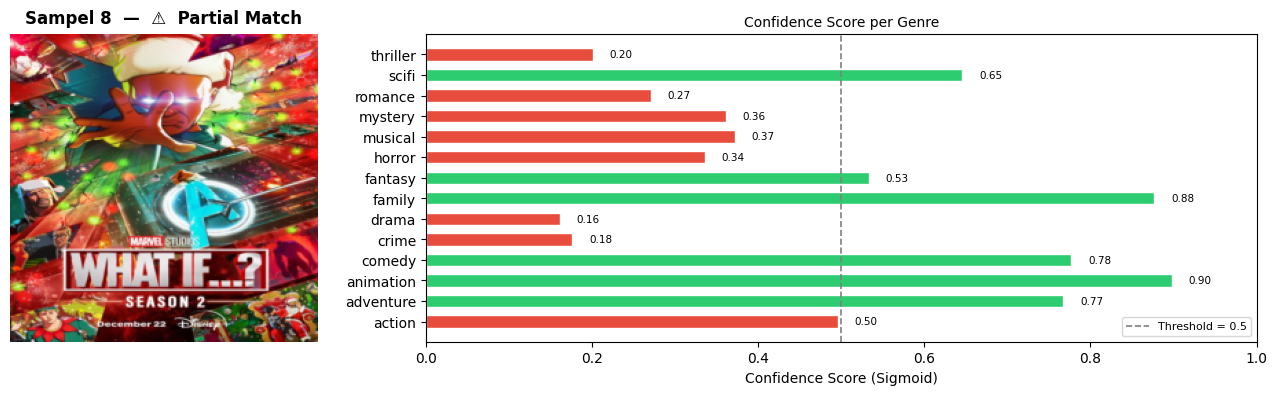


Sampel 8:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'animation', 'scifi']
  Prediksi     : ['adventure', 'animation', 'comedy', 'family', 'fantasy', 'scifi']
  Benar  (TP)  : ['adventure', 'animation', 'scifi']
  Terlewat(FN) : ['action']
  Salah  (FP)  : ['comedy', 'family', 'fantasy']
────────────────────────────────────────────────────────────


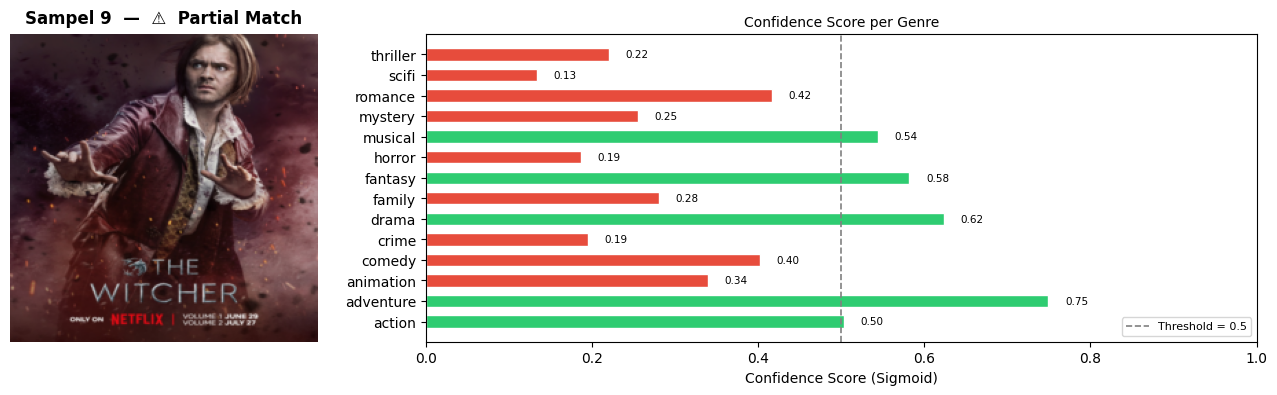


Sampel 9:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'drama']
  Prediksi     : ['action', 'adventure', 'drama', 'fantasy', 'musical']
  Benar  (TP)  : ['action', 'adventure', 'drama']
  Salah  (FP)  : ['fantasy', 'musical']
────────────────────────────────────────────────────────────


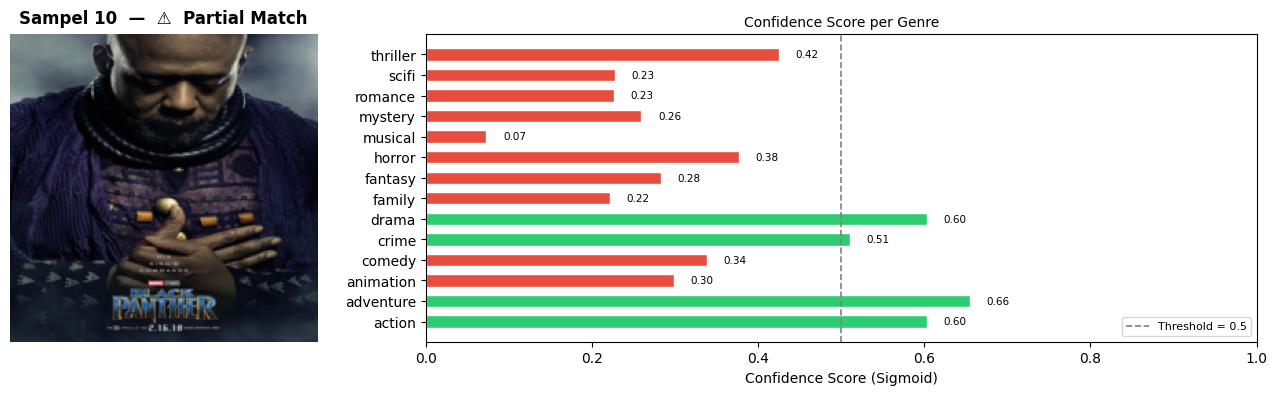


Sampel 10:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi']
  Prediksi     : ['action', 'adventure', 'crime', 'drama']
  Benar  (TP)  : ['action', 'adventure']
  Terlewat(FN) : ['scifi']
  Salah  (FP)  : ['crime', 'drama']
────────────────────────────────────────────────────────────

Semua hasil tersimpan : /kaggle/working/resnet50_results.pt

════════════════════════════════════════════════════════════
  RINGKASAN AKHIR — ResNet50
════════════════════════════════════════════════════════════
  Loss Function   : FocalLoss(gamma=2.0) + pos_weight boost
  Best metric     : Val F1-macro (bukan F1-micro)
  Threshold       : 0.5 (seragam semua model)
  Total epoch     : 50 (30+20)
  Best epoch      : 30
  Parameter       : 23,536,718
  Test F1-micro   : 0.5085
  Test F1-macro   : 0.4178
  Test mAP        : 0.5013
  Hamming Loss    : 0.2900
  Exact Match     : 0.0000
  AUC-ROC         : 0.6916
  Train Time/Epoch: 0.0s
  Infer Time/Img  : 2.73ms
═══════════

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [ ]:

# ════════════════════════════════════════════════════════════
# CELL 12 — Inferensi dengan fixed seed (data test seragam)
# ════════════════════════════════════════════════════════════

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

# Konstanta inferensi
INFER_SEED = 42
N_SAMPLES  = 10
INDICES_PATH = '/kaggle/working/sample_indices.npy'

print(f"INFERENSI — Contoh Prediksi pada Test Set")
print(f"Threshold  : {THRESHOLD} (seragam, sama dengan model lain)")
print(f"Seed       : {INFER_SEED} (seragam, sama dengan model lain)")
print(f"N sampel   : {N_SAMPLES}")
print("=" * 60)

# Pilih / load indeks sampel
if os.path.exists(INDICES_PATH):
    sample_indices = np.load(INDICES_PATH)
    print(f"✓ Loaded sample_indices dari: {INDICES_PATH}")
else:
    rng = np.random.default_rng(INFER_SEED)
    sample_indices = rng.choice(len(X_test), size=N_SAMPLES, replace=False)
    sample_indices = np.sort(sample_indices)
    np.save(INDICES_PATH, sample_indices)
    print(f"✓ sample_indices dibuat dan disimpan ke: {INDICES_PATH}")

print(f"  Indeks   : {sample_indices.tolist()}")
print()

# Inferensi
model.eval()

sample_imgs   = X_test[sample_indices].to(device)
sample_labels = y_test[sample_indices].numpy().astype(int)

with torch.no_grad():
    sample_outputs = model(sample_imgs)
    sample_probs   = torch.sigmoid(sample_outputs).cpu().numpy()

sample_preds = (sample_probs > THRESHOLD).astype(int)

# Denormalisasi gambar untuk ditampilkan
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor_img):
    """Kembalikan tensor [C,H,W] ke numpy [H,W,C] untuk imshow."""
    img = tensor_img.cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# Tampilkan hasil per sampel
print(f"{'─'*60}")

for idx in range(N_SAMPLES):
    true_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_labels[idx][i] == 1]
    pred_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_preds[idx][i]  == 1]
    correct = set(true_genres) & set(pred_genres)
    missed  = set(true_genres) - set(pred_genres)
    false_p = set(pred_genres) - set(true_genres)

    # Tentukan status match
    if set(true_genres) == set(pred_genres):
        status = "✅ Exact Match"
    elif correct:
        status = "⚠️  Partial Match"
    else:
        status = "❌ Wrong"

    # Gambar poster
    fig = plt.figure(figsize=(13, 4))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], figure=fig)

    # Panel kiri: poster
    ax_img = fig.add_subplot(gs[0])
    poster_np = denormalize(X_test[sample_indices[idx]])
    ax_img.imshow(poster_np)
    ax_img.axis('off')
    ax_img.set_title(
        f"Sampel {idx + 1}  —  {status}",
        fontsize=12, fontweight='bold', pad=8
    )

    # Panel kanan: probability bar chart
    ax_bar = fig.add_subplot(gs[1])
    probs  = sample_probs[idx]
    colors = ['#2ecc71' if probs[i] > THRESHOLD else '#e74c3c'
              for i in range(N_GENRES)]
    bars = ax_bar.barh(GENRE_COLS, probs, color=colors, edgecolor='white', height=0.6)
    ax_bar.axvline(x=THRESHOLD, color='gray', linestyle='--',
                   linewidth=1.2, label=f'Threshold = {THRESHOLD}')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel('Confidence Score (Sigmoid)')
    ax_bar.set_title('Confidence Score per Genre', fontsize=10)
    ax_bar.legend(fontsize=8, loc='lower right')

    # Tambahkan nilai di ujung bar
    for bar, prob in zip(bars, probs):
        ax_bar.text(
            min(prob + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
            f'{prob:.2f}', va='center', ha='left', fontsize=7.5
        )

    plt.tight_layout()
    plt.show()

    # Teks detail
    print(f"\nSampel {idx + 1}:")
    print(f"  Status       : {status}")
    print(f"  Label asli   : {true_genres}")
    print(f"  Prediksi     : {pred_genres}")
    print(f"  Benar  (TP)  : {sorted(correct)}")
    if missed:
        print(f"  Terlewat(FN) : {sorted(missed)}")
    if false_p:
        print(f"  Salah  (FP)  : {sorted(false_p)}")
    print(f"{'─'*60}")

# Simpan semua hasil
results_path = '/kaggle/working/resnet50_results.pt'
torch.save({
    "model_name"              : "ResNet50",
    "best_weights"            : "best_resnet50_fine_model.pth",
    "best_epoch"              : epochs,
    "total_params"            : total_params,
    "avg_epoch_time_s"        : avg_train_epoch_time,
    "avg_infer_ms"            : avg_inference_time * 1000,
    "threshold"               : THRESHOLD,
    "loss_function"           : "FocalLoss(gamma=2.0)",
    "val_loss"                : val_losses[-1] if len(val_losses) > 0 else None,
    "test_loss"               : test_loss,
    "test_f1_micro"           : micro_f1,
    "test_f1_macro"           : macro_f1,
    "test_f1_weighted"        : weighted_f1,
    "test_f1_per_genre"       : report_df["f1-score"].to_dict(),
    "test_precision_micro"    : precision_score(all_labels, all_preds, average="micro", zero_division=0),
    "test_precision_macro"    : precision_score(all_labels, all_preds, average="macro", zero_division=0),
    "test_precision_weighted" : precision_score(all_labels, all_preds, average="weighted", zero_division=0),
    "test_recall_micro"       : recall_score(all_labels, all_preds, average="micro", zero_division=0),
    "test_recall_macro"       : recall_score(all_labels, all_preds, average="macro", zero_division=0),
    "test_recall_weighted"    : recall_score(all_labels, all_preds, average="weighted", zero_division=0),
    "test_mAP"                : average_precision_score(all_labels, all_probs, average="macro"),
    "test_auc_roc"            : weighted_auc,
    "test_hamming_loss"       : hamming,
    "test_exact_match"        : exact_match,
    "history"                 : {"train_losses": train_losses, "val_losses": val_losses, "f1_scores": f1_scores},
    "genre_cols"              : GENRE_COLS,
    "phase1_epochs"           : epochs,
    "phase2_epochs"           : FINETUNE_EPOCH,
    "total_epochs"            : epochs + FINETUNE_EPOCH,
    "sample_indices"          : sample_indices.tolist(),
}, results_path)

print(f"\nSemua hasil tersimpan : {results_path}")
print(f"\n{'═'*60}")
print(f"  RINGKASAN AKHIR — ResNet50")
print(f"{'═'*60}")
print(f"  Loss Function   : FocalLoss(gamma=2.0) + pos_weight boost")
print(f"  Best metric     : Val F1-macro (bukan F1-micro)")
print(f"  Threshold       : {THRESHOLD} (seragam semua model)")
print(f"  Total epoch     : {epochs + FINETUNE_EPOCH} ({epochs}+{FINETUNE_EPOCH})")
print(f"  Best epoch      : {epochs}")
print(f"  Parameter       : {total_params:,}")
print(f"  Test F1-micro   : {micro_f1:.4f}")
print(f"  Test F1-macro   : {macro_f1:.4f}")
print(f"  Test mAP        : {average_precision_score(all_labels, all_probs, average='macro'):.4f}")
print(f"  Hamming Loss    : {hamming:.4f}")
print(f"  Exact Match     : {exact_match:.4f}")
print(f"  AUC-ROC         : {weighted_auc:.4f}")
print(f"  Train Time/Epoch: {avg_train_epoch_time if avg_train_epoch_time else 0:.1f}s")
print(f"  Infer Time/Img  : {avg_inference_time * 1000:.2f}ms")
print(f"{'═'*60}")
print(f"\nSelesai. Klik Save Version untuk menyimpan notebook.")

